# Blackjack: Monte Carlo Prediction vs. TD(0)

This notebook uses Blackjack to explain two model-free prediction methods. It first shows Monte Carlo Prediction step by step, then TD(0), and finally compares their learned state values.

## 1. Problem and What Will Be Learned

The problem is to estimate how good each Blackjack state is under a fixed Hit/Stick policy. The algorithms learn $V^\pi(s)$ from sampled games without being given transition probabilities.


Blackjack is a card game in which the player tries to obtain a hand value closer to $21$ than the dealer without exceeding $21$.

This implementation follows the common infinite-deck benchmark formulation:

- cards $2$ through $9$ have their face values,
- tens, jacks, queens, and kings are represented by value $10$,
- aces can count as $1$ or $11$,
- the deck is sampled with replacement,
- the dealer draws until the hand value is at least $17$.

### State

A state is

$$s=(\text{player sum},\text{dealer showing},\text{usable ace}).$$

For example,

$$(18,7,\text{True})$$

means:

- player sum $=18$,
- dealer showing $=7$,
- the player has a usable ace.

A usable ace is an ace currently counted as $11$ without causing a bust.

### Action

There are two actions:

```text
0 = Stick
1 = Hit
```

### Transition

The transition probabilities are **not provided to the learning algorithms**.

The agent only observes sampled transitions generated by the game:

$$(S_t,A_t,R_{t+1},S_{t+1}).$$

### Reward

At the terminal outcome:

$$R= \begin{cases} +1, & \text{player wins}\\ 0, & \text{draw}\\ -1, & \text{player loses} \end{cases}$$

Intermediate rewards are $0$.

### Fixed policy being evaluated

Both Monte Carlo and TD(0) evaluate the same policy:

```text
Hit   if player sum < 20
Stick if player sum >= 20
```

This controlled setup ensures that differences come from the prediction methods rather than different behavior policies.

### What is learned?

The algorithms estimate

$$V^\pi(s) = \mathbb{E}_\pi[G_t|S_t=s],$$

the expected return from each state when the fixed policy $\pi$ is followed.

No transition matrix is learned and no model of card probabilities is supplied to either algorithm.

### Mathematical prediction objective

For a policy $\pi$, the state-value function is

$$V^\pi(s)=\mathbb{E}_\pi[G_t\mid S_t=s].$$

If the transition model were known, the same value function would satisfy the Bellman expectation equation

$$V^\pi(s)=\sum_a\pi(a\mid s)\sum_{s'}P(s'\mid s,a)\left[R(s,a,s')+\gamma V^\pi(s')\right].$$

In this notebook, however, $P(s'\mid s,a)$ is **not given to the algorithms**. Monte Carlo and TD(0) approximate the same value function directly from sampled Blackjack experience.

The fixed deterministic policy can be written as

$$\pi(s)=\begin{cases}\text{Hit},&\text{player sum}<20\\\text{Stick},&\text{player sum}\ge20\end{cases}.$$


## 2. Imports

In [1]:
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

## 3. Blackjack Simulator

In [2]:
CARD_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]

HIT = 1
STICK = 0

ACTION_NAMES = {
    STICK: "Stick",
    HIT: "Hit",
}


def draw_card(rng):
    return rng.choice(CARD_VALUES)


def draw_hand(rng):
    return [draw_card(rng), draw_card(rng)]


def usable_ace(hand):
    return 1 in hand and sum(hand) + 10 <= 21


def hand_value(hand):
    value = sum(hand)

    if usable_ace(hand):
        value += 10

    return value


def is_bust(hand):
    return hand_value(hand) > 21


def score(hand):
    return 0 if is_bust(hand) else hand_value(hand)


def compare_scores(player_score, dealer_score):
    if player_score > dealer_score:
        return 1.0

    if player_score < dealer_score:
        return -1.0

    return 0.0


def state_from_hands(player_hand, dealer_hand):
    return (
        hand_value(player_hand),
        dealer_hand[0],
        usable_ace(player_hand),
    )


def fixed_policy(state):
    player_sum, _, _ = state
    return HIT if player_sum < 20 else STICK


class BlackjackEnv:
    def __init__(self, seed=0):
        self.rng = random.Random(seed)
        self.player = None
        self.dealer = None
        self.done = False

    def reset(self, seed=None):
        if seed is not None:
            self.rng = random.Random(seed)

        self.player = draw_hand(self.rng)
        self.dealer = draw_hand(self.rng)
        self.done = False

        # Ensure the player reaches the usual decision region.
        while hand_value(self.player) < 12:
            self.player.append(draw_card(self.rng))

        return state_from_hands(self.player, self.dealer)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode has already terminated.")

        if action == HIT:
            self.player.append(draw_card(self.rng))

            if is_bust(self.player):
                self.done = True
                return None, -1.0, True

            return state_from_hands(self.player, self.dealer), 0.0, False

        if action == STICK:
            while hand_value(self.dealer) < 17:
                self.dealer.append(draw_card(self.rng))

            self.done = True

            reward = compare_scores(
                score(self.player),
                score(self.dealer),
            )

            return None, reward, True

        raise ValueError("Invalid action.")

## 4. Inspect One State and Policy Decision

In [3]:
env = BlackjackEnv(seed=7)
state = env.reset(seed=7)

print("Sample state:", state)
print("Policy action:", ACTION_NAMES[fixed_policy(state)])
print("Player hand:", env.player)
print("Dealer hand:", env.dealer)

Sample state: (20, 7, True)
Policy action: Stick
Player hand: [6, 3, 1]
Dealer hand: [7, 10]


# 5. Monte Carlo Prediction

## How Monte Carlo Prediction Works

Monte Carlo prediction learns from **complete episodes**. The agent follows the fixed policy until the Blackjack game ends. Once the terminal reward is known, the algorithm moves backward through the episode and calculates the return from every time step. Each first-visited state is then updated toward its observed complete return. Because the complete future reward is used, Monte Carlo does not bootstrap from another estimated value, but it must wait for the episode to finish before updating from that episode.

For one sampled episode,

$$S_0,A_0,R_1,S_1,A_1,R_2,\ldots,S_T$$

the complete discounted return from time $t$ is

$$G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots+\gamma^{T-t-1}R_T.$$

The same return can be calculated backward with the recurrence

$$G_t=R_{t+1}+\gamma G_{t+1},\qquad G_T=0.$$

The Monte Carlo prediction error for a visited state is

$$e_t^{MC}=G_t-V(S_t).$$

The constant-step-size update used in this notebook is

$$V(S_t)\leftarrow V(S_t)+\alpha e_t^{MC}.$$

Equivalently,

$$V(S_t)\leftarrow V(S_t)+\alpha\left[G_t-V(S_t)\right].$$

This notebook uses **first-visit Monte Carlo prediction**, so if the same state appears more than once in one episode, only its first occurrence is updated.

## Monte Carlo Prediction Algorithm

```text
Input:
    fixed policy π
    learning rate α
    discount factor γ
    number of episodes

Initialize:
    V(s) = 0 for every state s

For each episode:

    1. Start a new Blackjack episode

       Observe the initial state S0

    2. Generate the complete episode using policy π

       while the episode is not terminal:

           A_t = π(S_t)

           execute A_t

           observe:
               R_t+1
               S_t+1
               terminal flag

           store:
               (S_t, A_t, R_t+1, S_t+1)

           if terminal:
               stop episode generation
           else:
               S_t = S_t+1

    3. After the episode ends, calculate returns backward

       set G = 0

       for t = T-1, T-2, ..., 0:

           G = R_t+1 + γG

           store G_t = G

    4. Update first-visited states

       create an empty set called visited

       for t = 0, 1, ..., T-1:

           if S_t is not in visited:

               add S_t to visited

               old_value = V(S_t)

               MC_error = G_t - old_value

               update = α × MC_error

               V(S_t) = old_value + update

    5. Continue with the next sampled episode

Output:
    V(s) ≈ V^π(s)
```

The key idea is therefore:

```text
complete episode
      ↓
terminal outcome
      ↓
calculate G_t backward
      ↓
compare G_t with V(S_t)
      ↓
update first-visited states
```


## 6. Generate One Complete Episode

In [4]:
def generate_episode(env, policy, seed=None):
    state = env.reset(seed=seed)
    episode = []

    while True:
        action = policy(state)
        next_state, reward, done = env.step(action)

        episode.append(
            {
                "state": state,
                "action": action,
                "reward": reward,
                "next_state": next_state,
                "done": done,
            }
        )

        if done:
            break

        state = next_state

    return episode


demo_episode = generate_episode(
    BlackjackEnv(seed=44),
    fixed_policy,
    seed=44,
)

for t, step in enumerate(demo_episode):
    print(
        f"t={t}: "
        f"S={step['state']}, "
        f"A={ACTION_NAMES[step['action']]}, "
        f"R_next={step['reward']}, "
        f"S_next={step['next_state']}, "
        f"done={step['done']}"
    )

t=0: S=(16, 9, False), A=Hit, R_next=0.0, S_next=(18, 9, False), done=False
t=1: S=(18, 9, False), A=Hit, R_next=0.0, S_next=(21, 9, False), done=False
t=2: S=(21, 9, False), A=Stick, R_next=1.0, S_next=None, done=True


## 7. Calculate the Monte Carlo Return at Every Time Step

The return is calculated backward using

$$G_t=R_{t+1}+\gamma G_{t+1}.$$

The code below prints every value used in the recurrence, including the reward, the already-computed future return, and the new $G_t$.

In [5]:
def discounted_returns(episode, gamma=1.0):
    returns = [0.0] * len(episode)
    G = 0.0

    for t in reversed(range(len(episode))):
        G = episode[t]["reward"] + gamma * G
        returns[t] = G

    return returns


gamma_demo = 1.0
demo_returns = discounted_returns(demo_episode, gamma=gamma_demo)

future_return = 0.0

for t in reversed(range(len(demo_episode))):
    reward = demo_episode[t]["reward"]
    G_t = demo_returns[t]

    print(f"Backward return calculation at t={t}")
    print("  State S_t       =", demo_episode[t]["state"])
    print("  Reward R_t+1    =", reward)
    print("  γ               =", gamma_demo)
    print("  G_t+1           =", future_return)
    print(f"  G_t = R_t+1 + γG_t+1")
    print(f"      = {reward} + {gamma_demo} × {future_return}")
    print(f"      = {G_t}")
    print()

    future_return = G_t


Backward return calculation at t=2
  State S_t       = (21, 9, False)
  Reward R_t+1    = 1.0
  γ               = 1.0
  G_t+1           = 0.0
  G_t = R_t+1 + γG_t+1
      = 1.0 + 1.0 × 0.0
      = 1.0

Backward return calculation at t=1
  State S_t       = (18, 9, False)
  Reward R_t+1    = 0.0
  γ               = 1.0
  G_t+1           = 1.0
  G_t = R_t+1 + γG_t+1
      = 0.0 + 1.0 × 1.0
      = 1.0

Backward return calculation at t=0
  State S_t       = (16, 9, False)
  Reward R_t+1    = 0.0
  γ               = 1.0
  G_t+1           = 1.0
  G_t = R_t+1 + γG_t+1
      = 0.0 + 1.0 × 1.0
      = 1.0



## 8. Print Every First-Visit Monte Carlo Update

For every first-visited state, the algorithm computes

$$e_t^{MC}=G_t-V(S_t)$$

and then

$$V_{\text{new}}(S_t)=V_{\text{old}}(S_t)+\alpha e_t^{MC}.$$

The code prints every numerical value used in both equations so the update can be followed directly.

In [6]:
alpha_demo = 0.10
V_demo = defaultdict(float)
visited = set()

for t, step in enumerate(demo_episode):
    state = step["state"]

    if state in visited:
        print(f"t={t}, state={state}")
        print("  State already appeared earlier in this episode.")
        print("  First-visit MC therefore skips this occurrence.")
        print()
        continue

    visited.add(state)

    G_t = demo_returns[t]
    old_value = V_demo[state]
    mc_error = G_t - old_value
    update = alpha_demo * mc_error
    new_value = old_value + update
    V_demo[state] = new_value

    print(f"t={t}, state={state}")
    print("  Old V(S_t)       =", old_value)
    print("  G_t              =", G_t)
    print("  MC error         =", mc_error)
    print("  α                =", alpha_demo)
    print("  α × MC error     =", update)
    print("  New V(S_t)       =", new_value)
    print()
    print(f"  Substitution:")
    print(f"  V_new = {old_value} + {alpha_demo} × ({G_t} - {old_value})")
    print(f"        = {new_value}")
    print()


t=0, state=(16, 9, False)
  Old V(S_t)       = 0.0
  G_t              = 1.0
  MC error         = 1.0
  α                = 0.1
  α × MC error     = 0.1
  New V(S_t)       = 0.1

  Substitution:
  V_new = 0.0 + 0.1 × (1.0 - 0.0)
        = 0.1

t=1, state=(18, 9, False)
  Old V(S_t)       = 0.0
  G_t              = 1.0
  MC error         = 1.0
  α                = 0.1
  α × MC error     = 0.1
  New V(S_t)       = 0.1

  Substitution:
  V_new = 0.0 + 0.1 × (1.0 - 0.0)
        = 0.1

t=2, state=(21, 9, False)
  Old V(S_t)       = 0.0
  G_t              = 1.0
  MC error         = 1.0
  α                = 0.1
  α × MC error     = 0.1
  New V(S_t)       = 0.1

  Substitution:
  V_new = 0.0 + 0.1 × (1.0 - 0.0)
        = 0.1



The code above uses the actual terminal reward generated by the game.

Because Blackjack gives $0$ on non-terminal transitions, with $\gamma=1$ every state in one episode receives the same final outcome as its undiscounted return.

## 9. Monte Carlo Prediction Function

The function below repeats the same operations over many sampled episodes. It generates an episode, computes all returns, applies first-visit updates, and records selected state values so their learning behavior can later be plotted.

In [7]:
def monte_carlo_prediction(
    episodes=30000,
    alpha=0.02,
    gamma=1.0,
    seed=123,
    tracked_states=None,
):
    env = BlackjackEnv(seed=seed)
    rng = random.Random(seed)

    V = defaultdict(float)
    history = {
        state: []
        for state in (tracked_states or [])
    }

    for episode_index in range(episodes):
        episode_seed = rng.randrange(1_000_000_000)

        episode = generate_episode(
            env,
            fixed_policy,
            seed=episode_seed,
        )

        returns = discounted_returns(
            episode,
            gamma=gamma,
        )

        visited = set()

        for t, step in enumerate(episode):
            state = step["state"]

            if state in visited:
                continue

            visited.add(state)

            G = returns[t]

            V[state] += alpha * (
                G - V[state]
            )

        for state in history:
            history[state].append(V[state])

    return V, history

# 10. TD(0) Prediction

## How TD(0) Prediction Works

TD(0) learns after **every transition** instead of waiting for the complete episode. The agent follows the fixed policy, observes the immediate reward and next state, and then forms a one-step estimate of the return. That estimate combines the observed reward with the current estimate of the next state's value. TD(0) therefore bootstraps: one learned estimate is used to improve another learned estimate.

After observing

$$S_t\rightarrow A_t\rightarrow R_{t+1}\rightarrow S_{t+1},$$

the one-step TD target is

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1}).$$

For a terminal transition,

$$V(S_{t+1})=0,$$

so the target reduces to

$$Y_t^{TD}=R_{t+1}.$$

The TD error measures the difference between the target and the current estimate:

$$\delta_t=Y_t^{TD}-V(S_t).$$

Substituting the target,

$$\delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t).$$

The state value is then updated by

$$V(S_t)\leftarrow V(S_t)+\alpha\delta_t.$$

Equivalently,

$$V(S_t)\leftarrow V(S_t)+\alpha\left[R_{t+1}+\gamma V(S_{t+1})-V(S_t)\right].$$

## TD(0) Prediction Algorithm

```text
Input:
    fixed policy π
    learning rate α
    discount factor γ
    number of episodes

Initialize:
    V(s) = 0 for every non-terminal state
    V(terminal) = 0

For each episode:

    1. Start a new Blackjack episode

       observe initial state S

    2. Repeat until terminal:

       a. Select the policy action

              A = π(S)

       b. Execute A

       c. Observe

              reward R
              next state S'
              terminal flag done

       d. Determine the bootstrap value

              if done:
                  next_value = 0
              else:
                  next_value = V(S')

       e. Compute the one-step TD target

              target = R + γ × next_value

       f. Compute the TD error

              TD_error = target - V(S)

       g. Compute the update amount

              update = α × TD_error

       h. Update the current-state value

              V(S) = V(S) + update

       i. If done:

              stop this episode

          otherwise:

              S = S'

    3. Continue with the next sampled episode

Output:
    V(s) ≈ V^π(s)
```

The step-by-step flow is

```text
observe S_t
    ↓
choose A_t from π
    ↓
observe R_t+1 and S_t+1
    ↓
compute bootstrap value V(S_t+1)
    ↓
compute TD target
    ↓
compute TD error
    ↓
update V(S_t)
    ↓
continue immediately
```


## 11. TD(0) Prediction Function

This function repeats the one-step TD update throughout many Blackjack episodes. Unlike Monte Carlo, it updates a state immediately after each sampled transition and therefore does not need to store the complete episode before learning.

In [8]:
def td0_prediction(
    episodes=30000,
    alpha=0.02,
    gamma=1.0,
    seed=456,
    tracked_states=None,
):
    env = BlackjackEnv(seed=seed)
    rng = random.Random(seed)

    V = defaultdict(float)
    history = {
        state: []
        for state in (tracked_states or [])
    }

    for episode_index in range(episodes):
        state = env.reset(
            seed=rng.randrange(
                1_000_000_000
            )
        )

        while True:
            action = fixed_policy(state)

            next_state, reward, done = env.step(
                action
            )

            next_value = (
                0.0
                if done
                else V[next_state]
            )

            td_target = (
                reward
                + gamma * next_value
            )

            td_error = (
                td_target
                - V[state]
            )

            V[state] += alpha * td_error

            if done:
                break

            state = next_state

        for tracked_state in history:
            history[
                tracked_state
            ].append(
                V[tracked_state]
            )

    return V, history

## 12. Code-Generated TD(0) Update Example

For one non-terminal transition, the notebook calculates the target, TD error, update amount, and new state value from values produced by the learned table.

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1})$$

$$\delta_t=Y_t^{TD}-V(S_t)$$

$$V_{\text{new}}(S_t)=V_{\text{old}}(S_t)+\alpha\delta_t$$

In [9]:
# First learn nonzero values so the bootstrap term is visible.
warm_values, _ = td0_prediction(
    episodes=5000,
    alpha=0.03,
    gamma=1.0,
    seed=80,
)

demo_env = BlackjackEnv(seed=90)
demo_rng = random.Random(90)

found = False

for attempt in range(500):
    state = demo_env.reset(
        seed=demo_rng.randrange(
            1_000_000_000
        )
    )

    action = fixed_policy(state)
    next_state, reward, done = demo_env.step(action)

    if not done and abs(warm_values[next_state]) > 1e-8:
        found = True
        break

if not found:
    raise RuntimeError(
        "Could not find a suitable non-terminal transition."
    )

alpha_demo = 0.03
gamma_demo = 1.0

old_value = warm_values[state]
next_value = warm_values[next_state]
td_target = reward + gamma_demo * next_value
td_error = td_target - old_value
new_value = old_value + alpha_demo * td_error

print("Observed transition")
print("  S_t              =", state)
print("  A_t              =", ACTION_NAMES[action])
print("  R_t+1            =", reward)
print("  S_t+1            =", next_state)
print()
print("Values used")
print("  V(S_t) before    =", old_value)
print("  V(S_t+1)         =", next_value)
print("  γ                 =", gamma_demo)
print("  α                 =", alpha_demo)
print()
print("TD target")
print(f"  target = R_t+1 + γV(S_t+1)")
print(f"         = {reward} + {gamma_demo} × {next_value}")
print(f"         = {td_target}")
print()
print("TD error")
print(f"  δ_t = target - V(S_t)")
print(f"      = {td_target} - {old_value}")
print(f"      = {td_error}")
print()
print("Value update")
print(f"  V_new = V_old + αδ_t")
print(f"        = {old_value} + {alpha_demo} × {td_error}")
print(f"        = {new_value}")


Observed transition
  S_t              = (17, 10, False)
  A_t              = Hit
  R_t+1            = 0.0
  S_t+1            = (19, 10, False)

Values used
  V(S_t) before    = -0.770060262116655
  V(S_t+1)         = -0.6338163397310594
  γ                 = 1.0
  α                 = 0.03

TD target
  target = R_t+1 + γV(S_t+1)
         = 0.0 + 1.0 × -0.6338163397310594
         = -0.6338163397310594

TD error
  δ_t = target - V(S_t)
      = -0.6338163397310594 - -0.770060262116655
      = 0.13624392238559557

Value update
  V_new = V_old + αδ_t
        = -0.770060262116655 + 0.03 × 0.13624392238559557
        = -0.7659729444450871


## 13. Print Every TD(0) Update in One Complete Episode

A complete representative episode is now processed transition by transition. At every step the notebook prints the observed transition and every number used in

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1}),$$

$$\delta_t=Y_t^{TD}-V(S_t),$$

and

$$V_{\text{new}}(S_t)=V_{\text{old}}(S_t)+\alpha\delta_t.$$

This makes the full TD learning mechanism visible from the first state until the terminal transition.

In [10]:
def trace_td_episode(initial_values, seed=2026, alpha=0.03, gamma=1.0):
    values = defaultdict(float, initial_values)
    env = BlackjackEnv(seed=seed)
    state = env.reset(seed=seed)
    step_number = 0

    while True:
        action = fixed_policy(state)
        next_state, reward, done = env.step(action)

        old_value = values[state]
        next_value = 0.0 if done else values[next_state]
        target = reward + gamma * next_value
        error = target - old_value
        update = alpha * error
        new_value = old_value + update
        values[state] = new_value

        print(f"Step {step_number}")
        print("  S_t               =", state)
        print("  A_t               =", ACTION_NAMES[action])
        print("  R_t+1             =", reward)
        print("  S_t+1             =", next_state)
        print("  Terminal?         =", done)
        print()
        print("  V(S_t) before     =", old_value)
        print("  V(S_t+1)          =", next_value)
        print("  γ                  =", gamma)
        print("  α                  =", alpha)
        print()
        print(f"  target = {reward} + {gamma} × {next_value}")
        print("         =", target)
        print(f"  error  = {target} - {old_value}")
        print("         =", error)
        print(f"  update = {alpha} × {error}")
        print("         =", update)
        print(f"  V_new  = {old_value} + {update}")
        print("         =", new_value)
        print()

        if done:
            print("Terminal transition reached. Episode finished.")
            break

        state = next_state
        step_number += 1

trace_td_episode(warm_values, seed=2026)


Step 0
  S_t               = (18, 9, False)
  A_t               = Hit
  R_t+1             = 0.0
  S_t+1             = (20, 9, False)
  Terminal?         = False

  V(S_t) before     = -0.7836162959271342
  V(S_t+1)          = 0.6410993553021052
  γ                  = 1.0
  α                  = 0.03

  target = 0.0 + 1.0 × 0.6410993553021052
         = 0.6410993553021052
  error  = 0.6410993553021052 - -0.7836162959271342
         = 1.4247156512292394
  update = 0.03 × 1.4247156512292394
         = 0.04274146953687718
  V_new  = -0.7836162959271342 + 0.04274146953687718
         = -0.740874826390257

Step 1
  S_t               = (20, 9, False)
  A_t               = Stick
  R_t+1             = 1.0
  S_t+1             = None
  Terminal?         = True

  V(S_t) before     = 0.6410993553021052
  V(S_t+1)          = 0.0
  γ                  = 1.0
  α                  = 0.03

  target = 1.0 + 1.0 × 0.0
         = 1.0
  error  = 1.0 - 0.6410993553021052
         = 0.35890064469789484
  update

The update above is produced from a real sampled Blackjack transition and the value table learned by the code.

This is bootstrapping:

$$V(S_t) \text{ is updated using } V(S_{t+1}).$$

## 14. Train Monte Carlo and TD(0) on the Same Policy

Both algorithms now estimate the same $V^\pi(s)$ for many sampled games. Using the same policy makes the comparison controlled: Monte Carlo differs from TD(0) only in how the learning target is formed.

Monte Carlo uses

$$Y_t^{MC}=G_t,$$

while TD(0) uses

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1}).$$

In [11]:
tracked_states = [
    (13, 2, False),
    (18, 6, False),
    (20, 10, False),
    (20, 10, True),
]

episodes = 30000
alpha = 0.02
gamma = 1.0

mc_values, mc_history = monte_carlo_prediction(
    episodes=episodes,
    alpha=alpha,
    gamma=gamma,
    seed=123,
    tracked_states=tracked_states,
)

td_values, td_history = td0_prediction(
    episodes=episodes,
    alpha=alpha,
    gamma=gamma,
    seed=456,
    tracked_states=tracked_states,
)

print(
    f"{'State':<20}"
    f"{'MC Value':>12}"
    f"{'TD(0) Value':>15}"
)

for state in tracked_states:
    print(
        f"{str(state):<20}"
        f"{mc_values[state]:>12.4f}"
        f"{td_values[state]:>15.4f}"
    )

State                   MC Value    TD(0) Value
(13, 2, False)           -0.4250        -0.3579
(18, 6, False)           -0.7382        -0.6848
(20, 10, False)           0.4949         0.4645
(20, 10, True)            0.4935         0.3746


## 15. Learning Curves for Selected States

The graphs track how $V(s)$ changes as more episodes are processed. A stable curve indicates that repeated updates are producing increasingly similar estimates for that state.

The plotted quantity is the current learned estimate

$$V_n(s),$$

where $n$ is the number of completed training episodes.

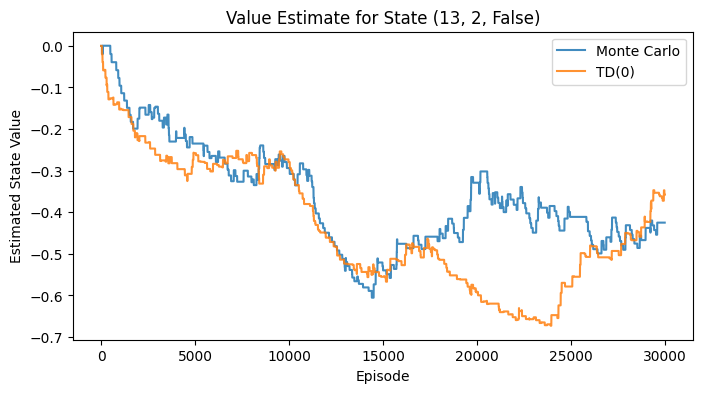

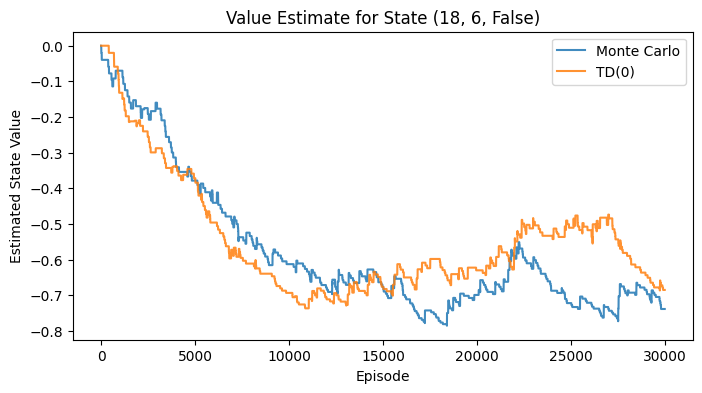

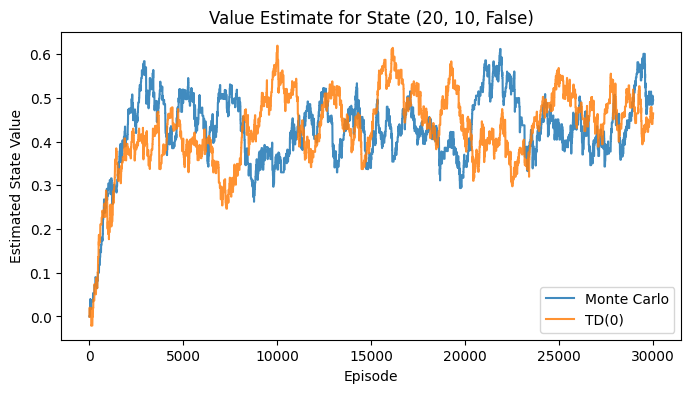

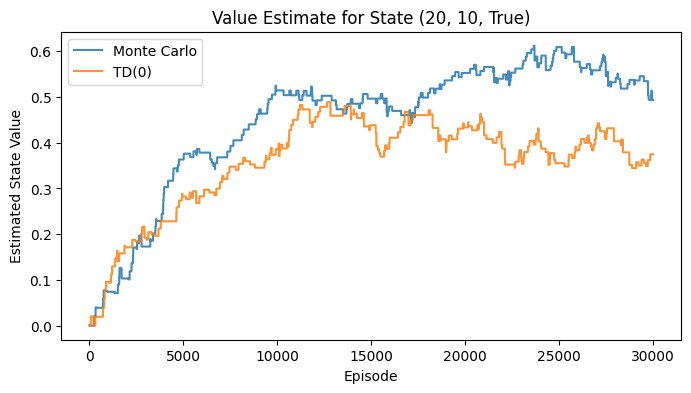

In [12]:
for state in tracked_states:
    plt.figure(figsize=(8, 4))

    plt.plot(
        mc_history[state],
        label="Monte Carlo",
        alpha=0.85,
    )

    plt.plot(
        td_history[state],
        label="TD(0)",
        alpha=0.85,
    )

    plt.xlabel("Episode")
    plt.ylabel("Estimated State Value")
    plt.title(
        f"Value Estimate for State {state}"
    )
    plt.legend()
    plt.show()

These curves show how the two model-free methods estimate the value of the same policy from sampled games.

Monte Carlo targets complete returns. TD(0) uses one-step bootstrapped targets, so the learning trajectories can differ even though both estimate the same $V^\pi$.

## 16. State-Value Heatmaps

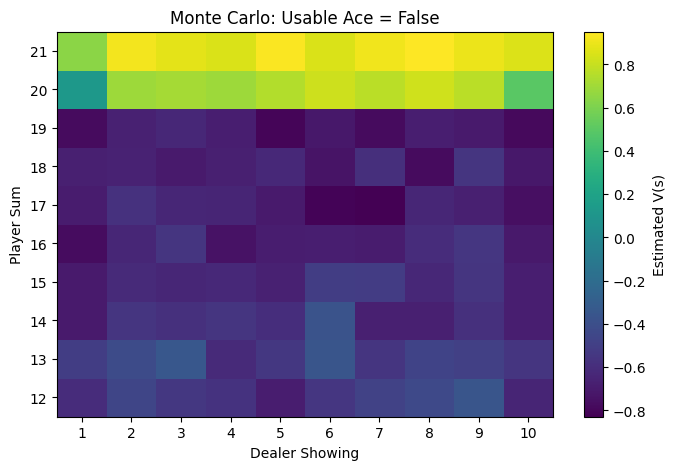

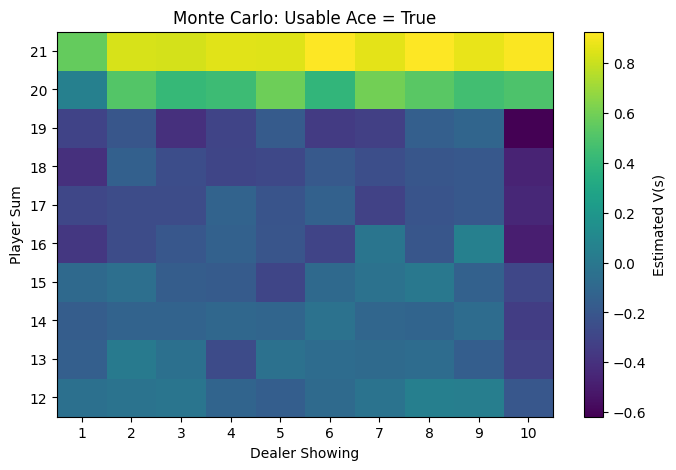

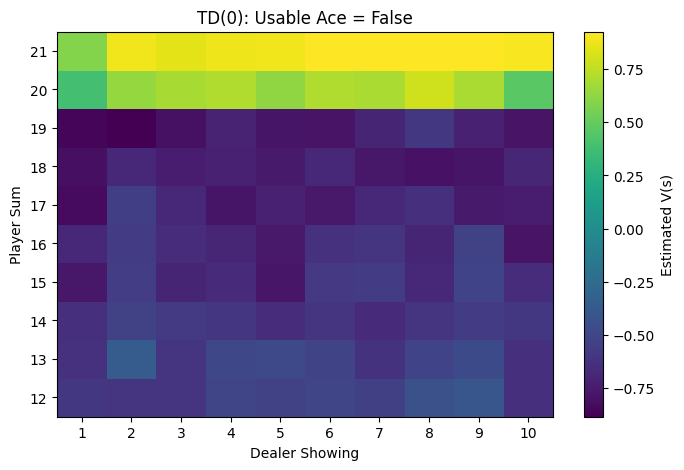

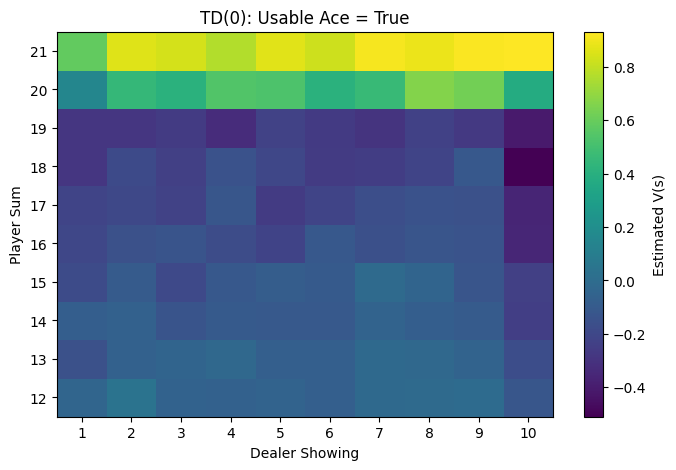

In [13]:
def value_matrix(values, usable):
    matrix = np.full((10, 10), np.nan)

    for player_sum in range(12, 22):
        for dealer_showing in range(1, 11):
            matrix[
                player_sum - 12,
                dealer_showing - 1,
            ] = values[
                (
                    player_sum,
                    dealer_showing,
                    usable,
                )
            ]

    return matrix


for method_name, values in [
    ("Monte Carlo", mc_values),
    ("TD(0)", td_values),
]:
    for usable in [False, True]:
        matrix = value_matrix(
            values,
            usable,
        )

        plt.figure(figsize=(8, 5))
        plt.imshow(
            matrix,
            origin="lower",
            aspect="auto",
        )

        plt.colorbar(
            label="Estimated V(s)"
        )

        plt.xticks(
            range(10),
            range(1, 11),
        )

        plt.yticks(
            range(10),
            range(12, 22),
        )

        plt.xlabel("Dealer Showing")
        plt.ylabel("Player Sum")
        plt.title(
            f"{method_name}: "
            f"Usable Ace = {usable}"
        )

        plt.show()

## 17. Simulation with 60 Printed Environment Transitions

After training, the fixed Blackjack policy is simulated again. This section is an **evaluation simulation**, not another learning pass: the learned value tables are kept fixed while new Blackjack transitions are generated.

A single Blackjack game is usually short, so the simulation continues across independent games until **60 transitions** have been printed.

For every transition it prints:

- episode number,
- step number within the episode,
- current state $S_t$,
- Monte Carlo estimate $V_{MC}(S_t)$,
- TD(0) estimate $V_{TD}(S_t)$,
- selected action $A_t$,
- reward $R_{t+1}$,
- next state $S_{t+1}$,
- terminal status.

Because both prediction methods evaluate the same fixed policy,

$$A_t=\pi(S_t),$$

the actions are the same. The comparison is between the learned state-value estimates, not between different policies.

In [14]:
def simulate_many_transitions(mc_values, td_values, total_transitions=60, seed=2026):
    rng = random.Random(seed)
    transition_count = 0
    episode_number = 0

    while transition_count < total_transitions:
        episode_number += 1
        env = BlackjackEnv(seed=rng.randrange(1_000_000_000))
        state = env.reset()
        episode_step = 0

        while True:
            action = fixed_policy(state)
            next_state, reward, done = env.step(action)

            transition_count += 1

            print(f"Transition {transition_count} | Episode {episode_number} | Episode step {episode_step}")
            print("  State S_t         =", state)
            print("  MC V(S_t)         =", round(mc_values[state], 4))
            print("  TD(0) V(S_t)      =", round(td_values[state], 4))
            print("  Action A_t        =", ACTION_NAMES[action])
            print("  Reward R_t+1      =", reward)
            print("  Next state S_t+1  =", next_state)
            print("  Terminal?         =", done)
            print()

            if transition_count >= total_transitions:
                break

            if done:
                break

            state = next_state
            episode_step += 1

        if transition_count >= total_transitions:
            break

    print("Total transitions printed =", transition_count)
    print("Total episodes used       =", episode_number)


simulate_many_transitions(
    mc_values,
    td_values,
    total_transitions=60,
    seed=2026,
)

Transition 1 | Episode 1 | Episode step 0
  State S_t         = (15, 10, False)
  MC V(S_t)         = -0.6777
  TD(0) V(S_t)      = -0.6577
  Action A_t        = Hit
  Reward R_t+1      = -1.0
  Next state S_t+1  = None
  Terminal?         = True

Transition 2 | Episode 2 | Episode step 0
  State S_t         = (13, 1, False)
  MC V(S_t)         = -0.5057
  TD(0) V(S_t)      = -0.6253
  Action A_t        = Hit
  Reward R_t+1      = -1.0
  Next state S_t+1  = None
  Terminal?         = True

Transition 3 | Episode 3 | Episode step 0
  State S_t         = (12, 10, False)
  MC V(S_t)         = -0.6472
  TD(0) V(S_t)      = -0.6325
  Action A_t        = Hit
  Reward R_t+1      = 0.0
  Next state S_t+1  = (18, 10, False)
  Terminal?         = False

Transition 4 | Episode 3 | Episode step 1
  State S_t         = (18, 10, False)
  MC V(S_t)         = -0.7177
  TD(0) V(S_t)      = -0.693
  Action A_t        = Hit
  Reward R_t+1      = -1.0
  Next state S_t+1  = None
  Terminal?         = True


# 18. Monte Carlo vs. TD(0)

| Property | Monte Carlo Prediction | TD(0) Prediction |
|---|---|---|
| Requires $P(s'|s,a)$ | No | No |
| Learns from sampled experience | Yes | Yes |
| Waits for episode end | Yes | No |
| Bootstraps | No | Yes |
| Target | $G_t$ | $R_{t+1}+\gamma V(S_{t+1})$ |
| Main estimate here | $V^\pi(s)$ | $V^\pi(s)$ |

The two targets are

$$Y_t^{MC}=G_t$$

and

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1}).$$

The corresponding update template is the same:

$$V(S_t)\leftarrow V(S_t)+\alpha\left[Y_t-V(S_t)\right].$$

What changes is the target $Y_t$.

```text
Monte Carlo
    ↓
wait for the complete episode
    ↓
compute complete return G_t
    ↓
update V(S_t)

TD(0)
    ↓
observe one transition
    ↓
compute R_t+1 + γV(S_t+1)
    ↓
update V(S_t) immediately
```

# 19. Summary

This notebook demonstrates model-free **state-value prediction** in Blackjack. Neither method receives the transition probabilities of the card game; both learn from sampled experience generated by the same fixed policy.

Monte Carlo learns from the complete return

$$G_t=R_{t+1}+\gamma G_{t+1}$$

and updates with

$$V(S_t)\leftarrow V(S_t)+\alpha[G_t-V(S_t)].$$

TD(0) forms the one-step target

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1})$$

and updates with

$$V(S_t)\leftarrow V(S_t)+\alpha[Y_t^{TD}-V(S_t)].$$

The notebook shows both algorithms from the conceptual explanation through the equations, pseudocode, numerical update values, full learning traces, training curves, state-value heatmaps, and a 60-transition evaluation simulation.

The next stage extends Temporal-Difference learning from $V(s)$ prediction to $Q(s,a)$ control with SARSA and Q-Learning.